In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Always set this — makes results reproducible
torch.manual_seed(42)

# Check GPU is available — must show 'cuda'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

transform = transforms.Compose([
    transforms.ToTensor(),           # converts image to tensor (0-255 → 0-1)
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean & std
])

train_data = datasets.MNIST(root='data', train=True, download=True, transform=transform)
test_data  = datasets.MNIST(root='data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=64, shuffle=False)

# Sanity check — always do this
images, labels = next(iter(train_loader))
print(images.shape)   # should be torch.Size([64, 1, 28, 28])
print(labels.shape)   # should be torch.Size([64])

cuda


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.61MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.4MB/s]

torch.Size([64, 1, 28, 28])
torch.Size([64])


In [ ]:
class DigitClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),           # 1x28x28 → 784
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Dropout(0.2),        # prevents overfitting
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 10)      # 10 classes (digits 0-9)
            # NO softmax here — CrossEntropyLoss does it internally
        )

    def forward(self, x):
        return self.network(x)

model = DigitClassifier().to(device)
print(model)

# Count parameters — should be ~235K
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

DigitClassifier(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=128, out_features=10, bias=True)
  )
)
Total parameters: 235,146


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()          # clear old gradients
        outputs = model(images)        # forward pass
        loss = criterion(outputs, labels)
        loss.backward()                # compute gradients
        optimizer.step()               # update weights

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()

    avg_loss = total_loss / len(loader)
    accuracy = correct / len(loader.dataset) * 100
    return avg_loss, accuracy


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0

    with torch.no_grad():              # no gradients needed for eval
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()

    avg_loss = total_loss / len(loader)
    accuracy = correct / len(loader.dataset) * 100
    return avg_loss, accuracy

In [ ]:
EPOCHS = 10

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    test_loss,  test_acc  = evaluate(model, test_loader, criterion)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

Epoch 01/10 | Train Loss: 0.2785 | Train Acc: 91.48% | Test Loss: 0.1145 | Test Acc: 96.42%
Epoch 02/10 | Train Loss: 0.1286 | Train Acc: 96.05% | Test Loss: 0.0879 | Test Acc: 97.14%
Epoch 03/10 | Train Loss: 0.1014 | Train Acc: 96.84% | Test Loss: 0.0804 | Test Acc: 97.54%
Epoch 04/10 | Train Loss: 0.0855 | Train Acc: 97.38% | Test Loss: 0.0762 | Test Acc: 97.64%
Epoch 05/10 | Train Loss: 0.0746 | Train Acc: 97.62% | Test Loss: 0.0746 | Test Acc: 97.73%
Epoch 06/10 | Train Loss: 0.0630 | Train Acc: 98.06% | Test Loss: 0.0639 | Test Acc: 98.11%
Epoch 07/10 | Train Loss: 0.0587 | Train Acc: 98.12% | Test Loss: 0.0629 | Test Acc: 98.05%
Epoch 08/10 | Train Loss: 0.0558 | Train Acc: 98.17% | Test Loss: 0.0682 | Test Acc: 97.97%
Epoch 09/10 | Train Loss: 0.0525 | Train Acc: 98.31% | Test Loss: 0.0667 | Test Acc: 98.10%
Epoch 10/10 | Train Loss: 0.0481 | Train Acc: 98.49% | Test Loss: 0.0609 | Test Acc: 98.28%


Model saved.


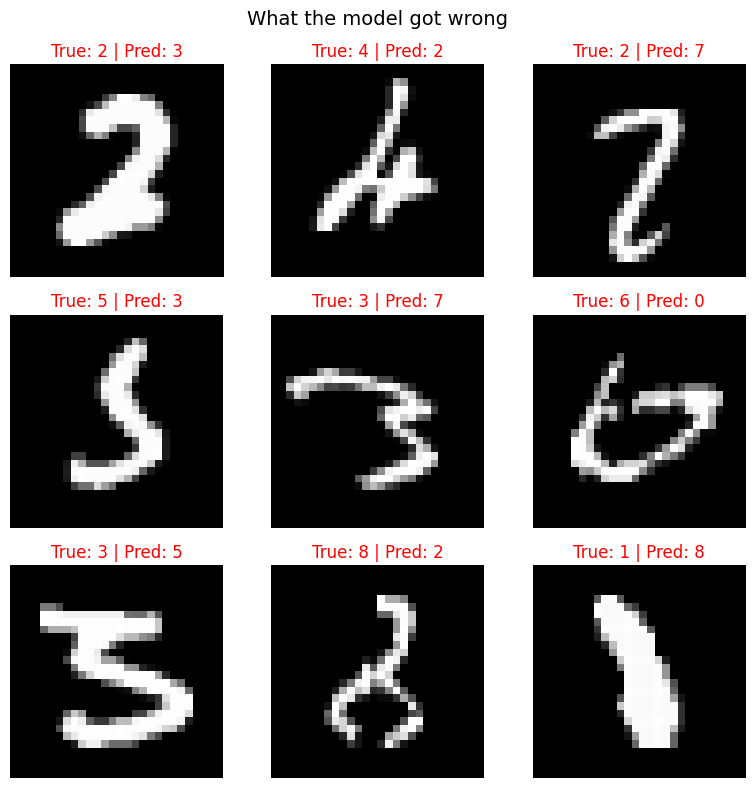

In [ ]:
# Save the model
torch.save(model.state_dict(), 'mnist_model.pth')
print("Model saved.")

# Visualize what the model gets WRONG — this is the important part
import matplotlib.pyplot as plt

model.eval()
wrong_images, wrong_preds, wrong_labels = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(1)

        mask = preds != labels
        wrong_images.extend(images[mask].cpu())
        wrong_preds.extend(preds[mask].cpu())
        wrong_labels.extend(labels[mask].cpu())

        if len(wrong_images) >= 9:
            break

fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(wrong_images[i].squeeze(), cmap='gray')
    ax.set_title(f"True: {wrong_labels[i]} | Pred: {wrong_preds[i]}", color='red')
    ax.axis('off')
plt.suptitle("What the model got wrong", fontsize=14)
plt.tight_layout()
plt.show()